In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'font.size': 10, 'axes.titlesize': 12, 'figure.dpi': 120})

# ── 데이터 로드 ──
base = '/data1/project/yeonu/065_multi_atac/GRN/results_output/'

files = {
    'Hepatocytes': f'{base}Hepatocyte_All_GRN_Weights.csv',
    'T_Cells':     f'{base}T_Cells_All_GRN_Weights.csv',
    'Mesenchymal': f'{base}Mesenchymal_All_GRN_Weights.csv',
    'Macrophages': f'{base}Macrophages_All_GRN_Weights.csv',
    'NK_Cells':    f'{base}NK_Cells_All_GRN_Weights.csv',
}

data = {}
for ct, path in files.items():
    df = pd.read_csv(path)
    data[ct] = df
    print(f'{ct}: {len(df)} edges, weight range [{df.grn_weight.min():.3f}, {df.grn_weight.max():.3f}]')

Hepatocytes: 29894 edges, weight range [-0.560, 0.391]
T_Cells: 845 edges, weight range [-0.140, 0.150]
Mesenchymal: 1175 edges, weight range [-0.115, 0.109]
Macrophages: 619 edges, weight range [-0.261, 0.089]
NK_Cells: 327 edges, weight range [-0.135, 0.091]


In [12]:
# ── Cutoff Sweep 함수 (실제 컬럼명: tf_name, gene, grn_weight) ──
def find_optimal_cutoff(df, cutoffs=np.arange(0.0, 0.51, 0.01)):
    results = []
    for c in cutoffs:
        filtered_df = df[df['grn_weight'].abs() > c]
        n_edges = len(filtered_df)
        n_tfs = filtered_df['tf_name'].nunique()
        n_targets = filtered_df['gene'].nunique()
        results.append([c, n_edges, n_tfs, n_targets])
    
    res_df = pd.DataFrame(results, columns=['cutoff', 'edges', 'tfs', 'targets'])
    return res_df

# ── Elbow 탐지 (Kneedle 방식) ──
def find_elbow(x, y):
    """직선 (x[0],y[0])→(x[-1],y[-1]) 대비 최대 거리 지점"""
    if len(x) < 3 or y[0] == y[-1]:
        return None, None
    x_norm = (x - x[0]) / (x[-1] - x[0] + 1e-10)
    y_norm = (y - y[0]) / (y[-1] - y[0] + 1e-10)
    dist = np.abs(y_norm - x_norm)
    idx = np.argmax(dist)
    return x[idx], idx

# ── 전체 Cell Type Sweep 수행 ──
sweep = {}
for ct, df in data.items():
    sweep[ct] = find_optimal_cutoff(df)

print('Sweep 완료')

Sweep 완료


In [13]:
# ── Elbow 요약 출력 ──
cutoffs = np.arange(0.0, 0.51, 0.01)

print('='*70)
print('ELBOW & RECOMMENDED CUTOFF SUMMARY')
print('='*70)

for ct, res_df in sweep.items():
    total = res_df['edges'].iloc[0]
    if total == 0:
        continue
    print(f'\n  [{ct}] (total {total} edges)')

    for label, col in [('Edges', 'edges'), ('TFs', 'tfs'), ('Targets', 'targets')]:
        arr = res_df[col].values
        elbow_val, elbow_idx = find_elbow(cutoffs[:len(arr)], arr.astype(float))
        if elbow_val is not None:
            print(f'    {label} elbow:  ρ > {elbow_val:.2f} → {int(arr[elbow_idx])} '
                  f'({arr[elbow_idx]/arr[0]*100:.1f}% of total)')

    r01 = res_df[res_df['cutoff'].round(2) == 0.10].iloc[0]
    r02 = res_df[res_df['cutoff'].round(2) == 0.20].iloc[0]
    print(f'    ρ > 0.10: {int(r01.edges)} edges, {int(r01.tfs)} TFs, {int(r01.targets)} targets')
    print(f'    ρ > 0.20: {int(r02.edges)} edges, {int(r02.tfs)} TFs, {int(r02.targets)} targets')

ELBOW & RECOMMENDED CUTOFF SUMMARY

  [Hepatocytes] (total 29894 edges)
    Edges elbow:  ρ > 0.19 → 7338 (24.5% of total)
    TFs elbow:  ρ > 0.15 → 534 (82.5% of total)
    Targets elbow:  ρ > 0.27 → 101 (32.0% of total)
    ρ > 0.10: 15583 edges, 585 TFs, 269 targets
    ρ > 0.20: 6772 edges, 425 TFs, 145 targets

  [T_Cells] (total 845 edges)
    Edges elbow:  ρ > 0.05 → 74 (8.8% of total)
    TFs elbow:  ρ > 0.08 → 35 (8.5% of total)
    Targets elbow:  ρ > 0.07 → 1 (12.5% of total)
    ρ > 0.10: 22 edges, 22 TFs, 1 targets
    ρ > 0.20: 0 edges, 0 TFs, 0 targets

  [Mesenchymal] (total 1175 edges)
    Edges elbow:  ρ > 0.08 → 33 (2.8% of total)
    TFs elbow:  ρ > 0.09 → 15 (3.6% of total)
    Targets elbow:  ρ > 0.12 → 0 (0.0% of total)
    ρ > 0.10: 8 edges, 8 TFs, 3 targets
    ρ > 0.20: 0 edges, 0 TFs, 0 targets

  [Macrophages] (total 619 edges)
    Edges elbow:  ρ > 0.09 → 81 (13.1% of total)
    TFs elbow:  ρ > 0.15 → 36 (11.2% of total)
    Targets elbow:  ρ > 0.09 → 1 (1

/tmp/ipykernel_3794793/871975757.py:23: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-^" (-> linestyle='-'). The keyword argument will take precedence.
  axes[i, 1].plot(res_df['cutoff'], res_df['targets'], '-^', color=col_c, markersize=2, lw=1.5, alpha=0.6, ls='--', label='Targets')


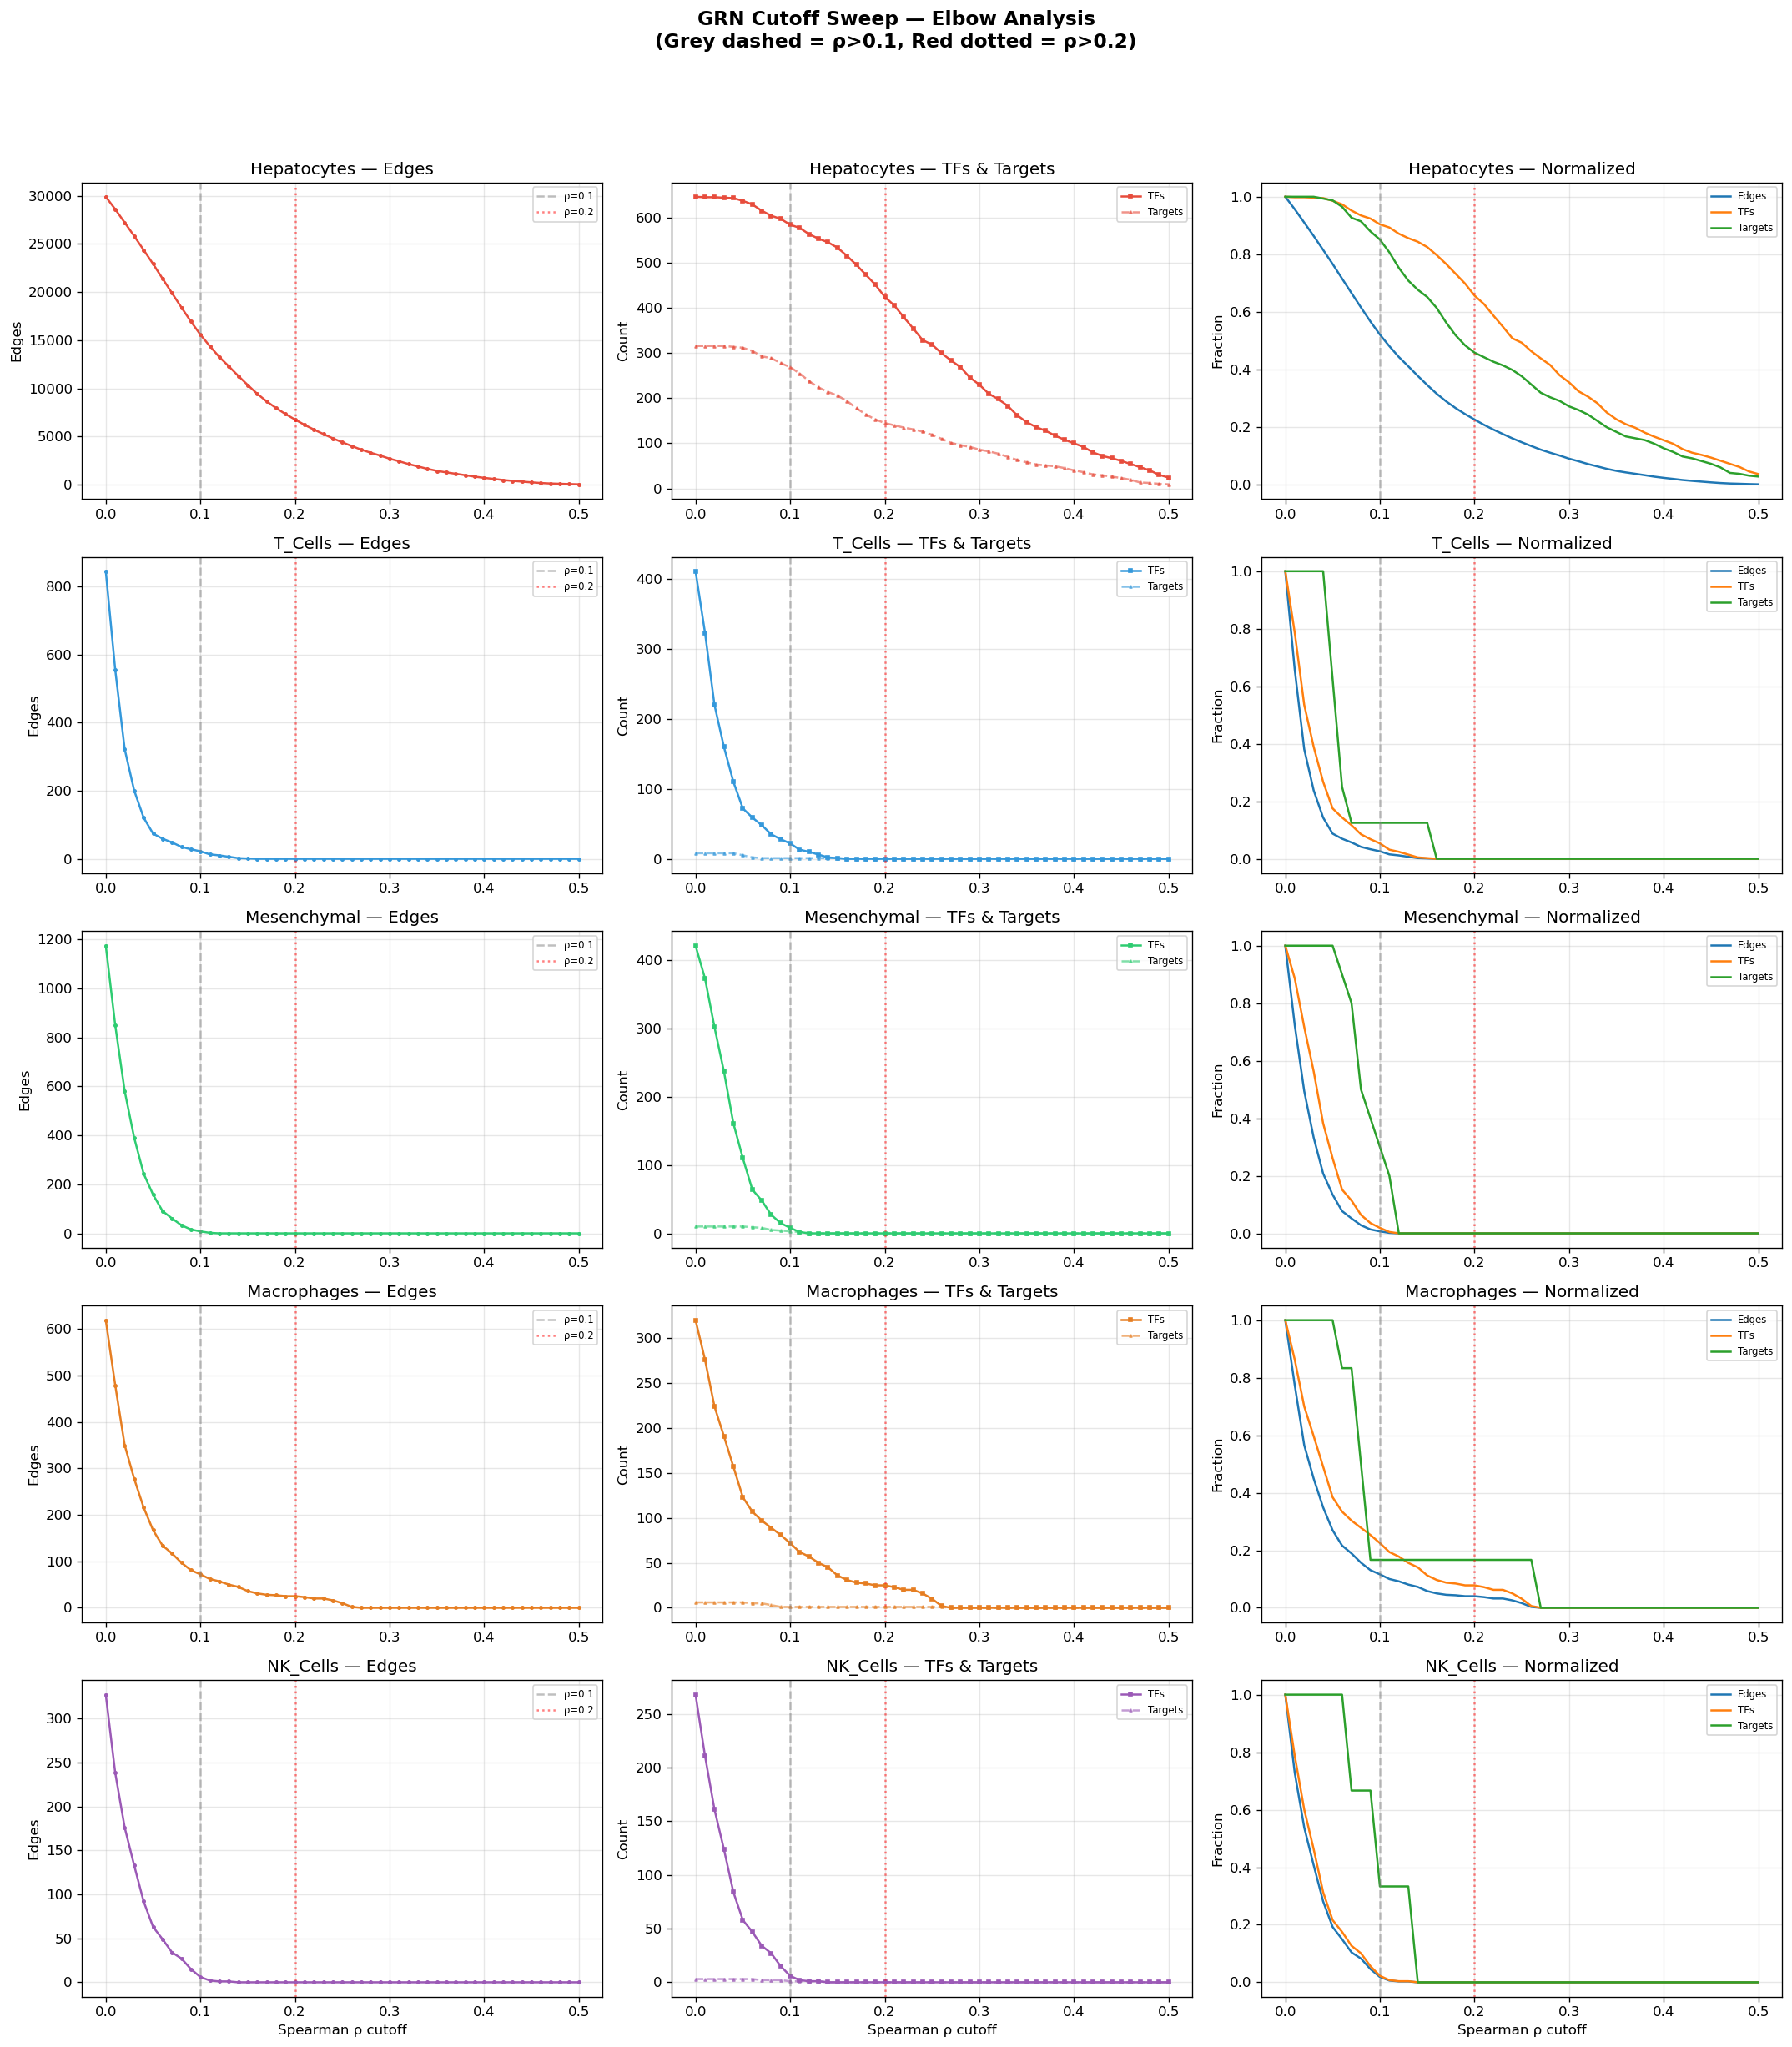

In [14]:
# ── 전체 Cell Type Elbow 시각화 ──
colors = {
    'Hepatocytes': '#E74C3C', 'T_Cells': '#3498DB',
    'Mesenchymal': '#2ECC71', 'Macrophages': '#E67E22', 'NK_Cells': '#9B59B6',
}

fig, axes = plt.subplots(len(sweep), 3, figsize=(18, 4 * len(sweep)))
if len(sweep) == 1:
    axes = axes[np.newaxis, :]

for i, (ct, res_df) in enumerate(sweep.items()):
    col_c = colors.get(ct, '#333')

    # Edges
    axes[i, 0].plot(res_df['cutoff'], res_df['edges'], '-o', color=col_c, markersize=2, lw=1.5)
    axes[i, 0].axvline(x=0.10, color='grey', ls='--', alpha=0.5, label='ρ=0.1')
    axes[i, 0].axvline(x=0.20, color='red', ls=':', alpha=0.5, label='ρ=0.2')
    axes[i, 0].set_title(f'{ct} — Edges'); axes[i, 0].set_ylabel('Edges')
    axes[i, 0].legend(fontsize=7); axes[i, 0].grid(True, alpha=0.3)

    # TFs & Targets
    axes[i, 1].plot(res_df['cutoff'], res_df['tfs'], '-s', color=col_c, markersize=2, lw=1.5, label='TFs')
    axes[i, 1].plot(res_df['cutoff'], res_df['targets'], '-^', color=col_c, markersize=2, lw=1.5, alpha=0.6, ls='--', label='Targets')
    axes[i, 1].axvline(x=0.10, color='grey', ls='--', alpha=0.5)
    axes[i, 1].axvline(x=0.20, color='red', ls=':', alpha=0.5)
    axes[i, 1].set_title(f'{ct} — TFs & Targets'); axes[i, 1].set_ylabel('Count')
    axes[i, 1].legend(fontsize=7); axes[i, 1].grid(True, alpha=0.3)

    # Normalized (0~1)
    for col, label in [('edges', 'Edges'), ('tfs', 'TFs'), ('targets', 'Targets')]:
        vals = res_df[col].values
        if vals[0] > 0:
            axes[i, 2].plot(res_df['cutoff'], vals / vals[0], '-', lw=1.5, label=label)
    axes[i, 2].axvline(x=0.10, color='grey', ls='--', alpha=0.5)
    axes[i, 2].axvline(x=0.20, color='red', ls=':', alpha=0.5)
    axes[i, 2].set_title(f'{ct} — Normalized'); axes[i, 2].set_ylabel('Fraction')
    axes[i, 2].legend(fontsize=7); axes[i, 2].grid(True, alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel('Spearman ρ cutoff')

plt.suptitle('GRN Cutoff Sweep — Elbow Analysis\n(Grey dashed = ρ>0.1, Red dotted = ρ>0.2)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

---
## 절대값 아닌 버전 (ρ > cutoff, 양수만)

In [15]:
# ── Cutoff Sweep 함수 (절대값 아닌 버전: ρ > cutoff, 양수만) ──
def find_optimal_cutoff_pos(df, cutoffs=np.arange(0.0, 0.51, 0.01)):
    results = []
    for c in cutoffs:
        filtered_df = df[df['grn_weight'] > c]
        n_edges = len(filtered_df)
        n_tfs = filtered_df['tf_name'].nunique()
        n_targets = filtered_df['gene'].nunique()
        results.append([c, n_edges, n_tfs, n_targets])
    
    res_df = pd.DataFrame(results, columns=['cutoff', 'edges', 'tfs', 'targets'])
    return res_df

# ── 전체 Cell Type Sweep 수행 (양수만) ──
sweep_pos = {}
for ct, df in data.items():
    sweep_pos[ct] = find_optimal_cutoff_pos(df)

print('Sweep 완료 (양수만)')

Sweep 완료 (양수만)


In [16]:
# ── Elbow 요약 출력 (양수만) ──
cutoffs = np.arange(0.0, 0.51, 0.01)

print('='*70)
print('ELBOW & RECOMMENDED CUTOFF SUMMARY (양수만, ρ > cutoff)')
print('='*70)

for ct, res_df in sweep_pos.items():
    total = res_df['edges'].iloc[0]
    if total == 0:
        continue
    print(f'\n  [{ct}] (total {total} edges with ρ > 0)')

    for label, col in [('Edges', 'edges'), ('TFs', 'tfs'), ('Targets', 'targets')]:
        arr = res_df[col].values
        elbow_val, elbow_idx = find_elbow(cutoffs[:len(arr)], arr.astype(float))
        if elbow_val is not None:
            print(f'    {label} elbow:  ρ > {elbow_val:.2f} → {int(arr[elbow_idx])} '
                  f'({arr[elbow_idx]/arr[0]*100:.1f}% of total)')

    r01 = res_df[res_df['cutoff'].round(2) == 0.10].iloc[0]
    r02 = res_df[res_df['cutoff'].round(2) == 0.20].iloc[0]
    print(f'    ρ > 0.10: {int(r01.edges)} edges, {int(r01.tfs)} TFs, {int(r01.targets)} targets')
    print(f'    ρ > 0.20: {int(r02.edges)} edges, {int(r02.tfs)} TFs, {int(r02.targets)} targets')

ELBOW & RECOMMENDED CUTOFF SUMMARY (양수만, ρ > cutoff)

  [Hepatocytes] (total 3890 edges with ρ > 0)
    Edges elbow:  ρ > 0.11 → 471 (12.1% of total)
    TFs elbow:  ρ > 0.16 → 43 (7.7% of total)
    Targets elbow:  ρ > 0.19 → 52 (18.4% of total)
    ρ > 0.10: 562 edges, 157 TFs, 122 targets
    ρ > 0.20: 93 edges, 21 TFs, 47 targets

  [T_Cells] (total 245 edges with ρ > 0)
    Edges elbow:  ρ > 0.05 → 25 (10.2% of total)
    TFs elbow:  ρ > 0.08 → 13 (6.5% of total)
    Targets elbow:  ρ > 0.06 → 1 (12.5% of total)
    ρ > 0.10: 10 edges, 10 TFs, 1 targets
    ρ > 0.20: 0 edges, 0 TFs, 0 targets

  [Mesenchymal] (total 580 edges with ρ > 0)
    Edges elbow:  ρ > 0.09 → 11 (1.9% of total)
    TFs elbow:  ρ > 0.10 → 5 (1.7% of total)
    Targets elbow:  ρ > 0.11 → 0 (0.0% of total)
    ρ > 0.10: 5 edges, 5 TFs, 1 targets
    ρ > 0.20: 0 edges, 0 TFs, 0 targets

  [Macrophages] (total 380 edges with ρ > 0)
    Edges elbow:  ρ > 0.09 → 0 (0.0% of total)
    TFs elbow:  ρ > 0.09 → 0 (0.0%

/tmp/ipykernel_3794793/602273284.py:23: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-^" (-> linestyle='-'). The keyword argument will take precedence.
  axes[i, 1].plot(res_df['cutoff'], res_df['targets'], '-^', color=col_c, markersize=2, lw=1.5, alpha=0.6, ls='--', label='Targets')
/tmp/ipykernel_3794793/602273284.py:44: UserWarning: Glyph 50577 (\N{HANGUL SYLLABLE YANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.98])
/tmp/ipykernel_3794793/602273284.py:44: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.98])
/tmp/ipykernel_3794793/602273284.py:44: UserWarning: Glyph 47564 (\N{HANGUL SYLLABLE MAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.98])
/data1/project/yeonu/Anaconda3/envs/viz/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50577 (\N{HANGUL SYLLABLE YANG}) missing

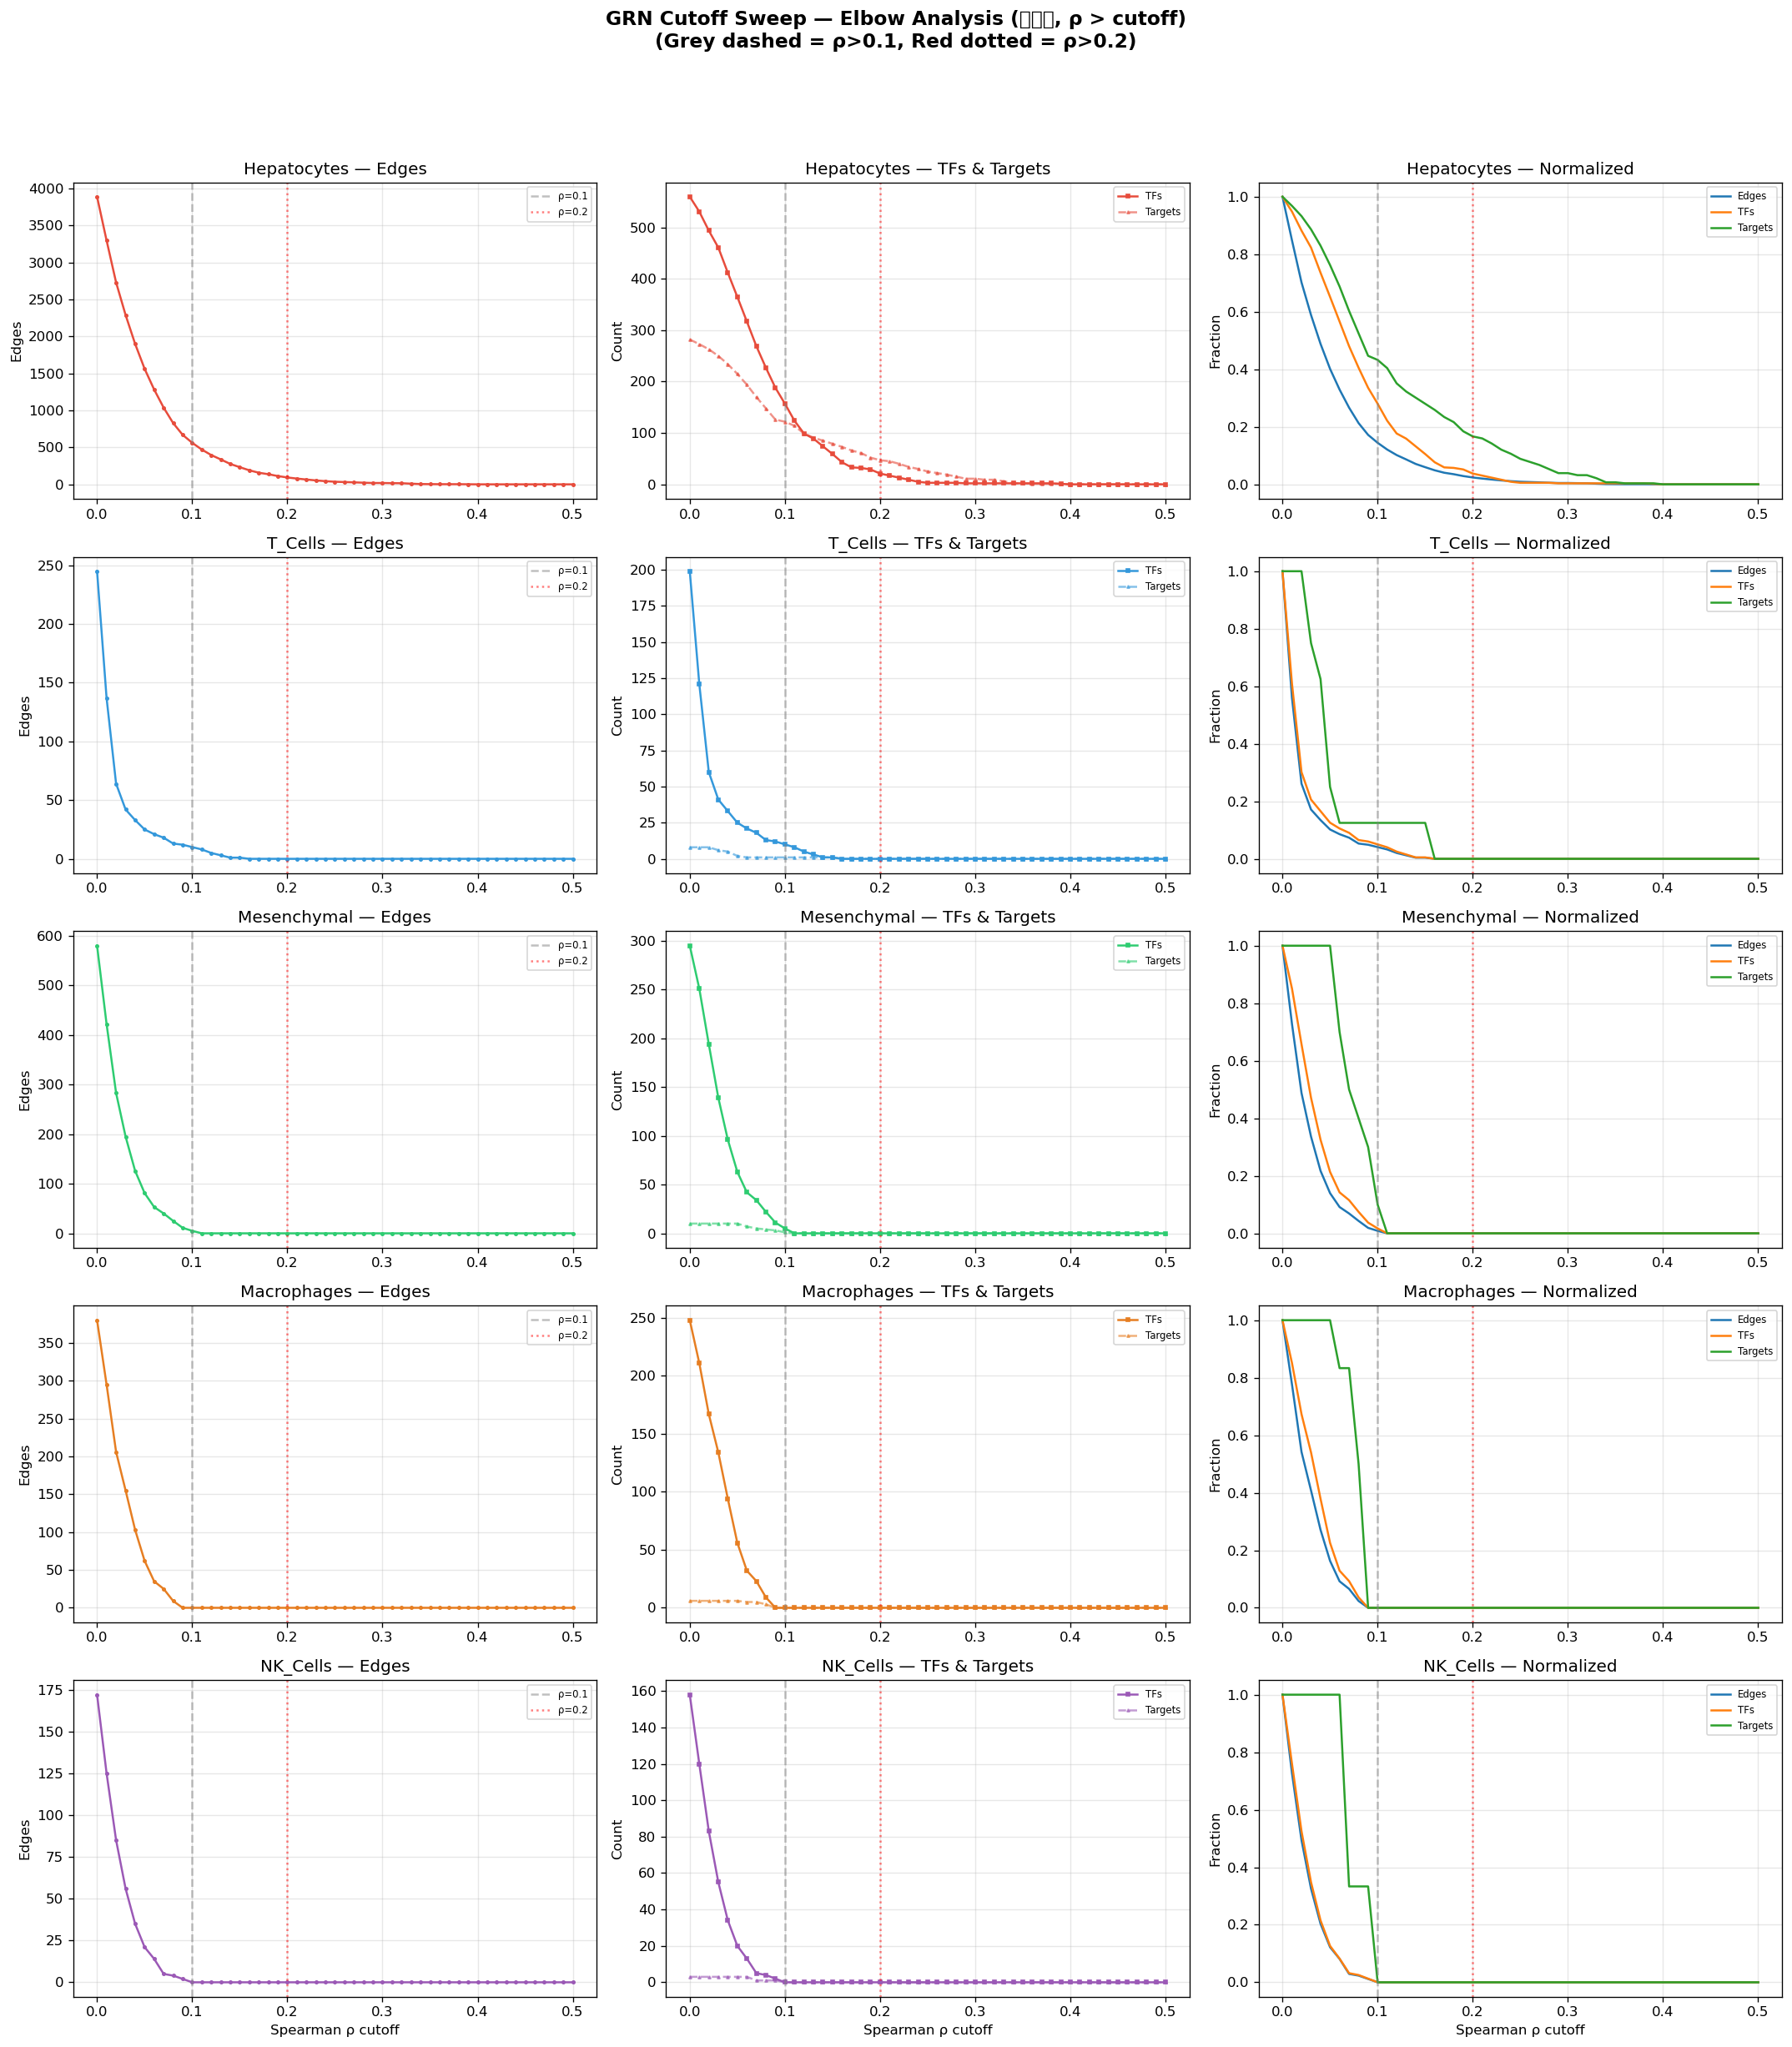

In [17]:
# ── 전체 Cell Type Elbow 시각화 (양수만) ──
colors = {
    'Hepatocytes': '#E74C3C', 'T_Cells': '#3498DB',
    'Mesenchymal': '#2ECC71', 'Macrophages': '#E67E22', 'NK_Cells': '#9B59B6',
}

fig, axes = plt.subplots(len(sweep_pos), 3, figsize=(18, 4 * len(sweep_pos)))
if len(sweep_pos) == 1:
    axes = axes[np.newaxis, :]

for i, (ct, res_df) in enumerate(sweep_pos.items()):
    col_c = colors.get(ct, '#333')

    # Edges
    axes[i, 0].plot(res_df['cutoff'], res_df['edges'], '-o', color=col_c, markersize=2, lw=1.5)
    axes[i, 0].axvline(x=0.10, color='grey', ls='--', alpha=0.5, label='ρ=0.1')
    axes[i, 0].axvline(x=0.20, color='red', ls=':', alpha=0.5, label='ρ=0.2')
    axes[i, 0].set_title(f'{ct} — Edges'); axes[i, 0].set_ylabel('Edges')
    axes[i, 0].legend(fontsize=7); axes[i, 0].grid(True, alpha=0.3)

    # TFs & Targets
    axes[i, 1].plot(res_df['cutoff'], res_df['tfs'], '-s', color=col_c, markersize=2, lw=1.5, label='TFs')
    axes[i, 1].plot(res_df['cutoff'], res_df['targets'], '-^', color=col_c, markersize=2, lw=1.5, alpha=0.6, ls='--', label='Targets')
    axes[i, 1].axvline(x=0.10, color='grey', ls='--', alpha=0.5)
    axes[i, 1].axvline(x=0.20, color='red', ls=':', alpha=0.5)
    axes[i, 1].set_title(f'{ct} — TFs & Targets'); axes[i, 1].set_ylabel('Count')
    axes[i, 1].legend(fontsize=7); axes[i, 1].grid(True, alpha=0.3)

    # Normalized (0~1)
    for col, label in [('edges', 'Edges'), ('tfs', 'TFs'), ('targets', 'Targets')]:
        vals = res_df[col].values
        if vals[0] > 0:
            axes[i, 2].plot(res_df['cutoff'], vals / vals[0], '-', lw=1.5, label=label)
    axes[i, 2].axvline(x=0.10, color='grey', ls='--', alpha=0.5)
    axes[i, 2].axvline(x=0.20, color='red', ls=':', alpha=0.5)
    axes[i, 2].set_title(f'{ct} — Normalized'); axes[i, 2].set_ylabel('Fraction')
    axes[i, 2].legend(fontsize=7); axes[i, 2].grid(True, alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel('Spearman ρ cutoff')

plt.suptitle('GRN Cutoff Sweep — Elbow Analysis (양수만, ρ > cutoff)\n(Grey dashed = ρ>0.1, Red dotted = ρ>0.2)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()